# Thyroid Cancer Recurrence Prediction Pipeline

Complete end-to-end machine learning pipeline for predicting thyroid cancer recurrence from patient data.

## Overview
- Dataset: 383 patients with clinical features
- Target: Recurrence (Yes/No)
- Focus: High sensitivity for clinical decision support

In [3]:
pip install python>=3.8 pandas>=1.4.0 numpy>=1.21.0 scikit-learn>=1.0.0 matplotlib>=3.5.0 seaborn>=0.11.0 xgboost>=1.6.0 lightgbm>=3.3.0 catboost>=1.0.0 shap>=0.41.0 imblearn>=0.9.0 joblib>=1.1.0 optuna>=3.0.0 fastapi>=0.85.0 uvicorn>=0.18.0 streamlit>=1.12.0 jupyter>=1.0.0 notebook>=6.4.0


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement python (from versions: none)
ERROR: No matching distribution found for python


In [5]:
pip install catboost

   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.5 MB ? eta -:--:--
    --------------------------------------- 2.4/102.5 MB 8.9 MB/s eta 0:00:12
   - -------------------------------------- 4.7/102.5 MB 9.8 MB/s eta 0:00:10
   --- ------------------------------------ 7.9/102.5 MB 11.0 MB/s eta 0:00:09
   --- ------------------------------------ 8.9/102.5 MB 9.9 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/102.5 MB 10.5 MB/s eta 0:00:09
   ----- ---------------------------------- 14.2/102.5 MB 10.8 MB/s eta 0:00:09
   ------ --------------------------------- 17.0/102.5 MB 11.0 MB/s eta 0:00:08
   ------- -------------------------------- 19.4/102.5 MB 11.0 MB/s eta 0:00:08
   -------- ------------------------------- 22.8/102.5 MB 11.6 MB/s eta 0:00:07
   --------- ------------------------------ 25.4/102.5 MB 11.8 MB/s eta 0:00:07
   ---------- ----------------------------- 28.0/102.5 MB 11.9 MB

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Set random seed
np.random.seed(42)

c:\Users\DipaliAgrawal\OneDrive - Involead Services Private Limited\Desktop\UM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Initial Checks

In [9]:
# Load dataset
data_path = r'C:\Users\DipaliAgrawal\OneDrive - Involead Services Private Limited\Desktop\UM\thyroid_cancer\thyroid_cancer\dataset.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 10 rows:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique values for categorical columns:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

print("\nTarget distribution:")
print(df['Recurred'].value_counts())
print(f"Positive class percentage: {df['Recurred'].value_counts()['Yes']/len(df)*100:.1f}%")

Dataset shape: (383, 17)

First 10 rows:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
5,52,M,Yes,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Indeterminate,No
6,41,F,No,Yes,No,Clinical Hyperthyroidism,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
7,46,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No



Data types:
Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                object
dtype: object

Missing values per column:
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Re

## 2. Exploratory Data Analysis (EDA)

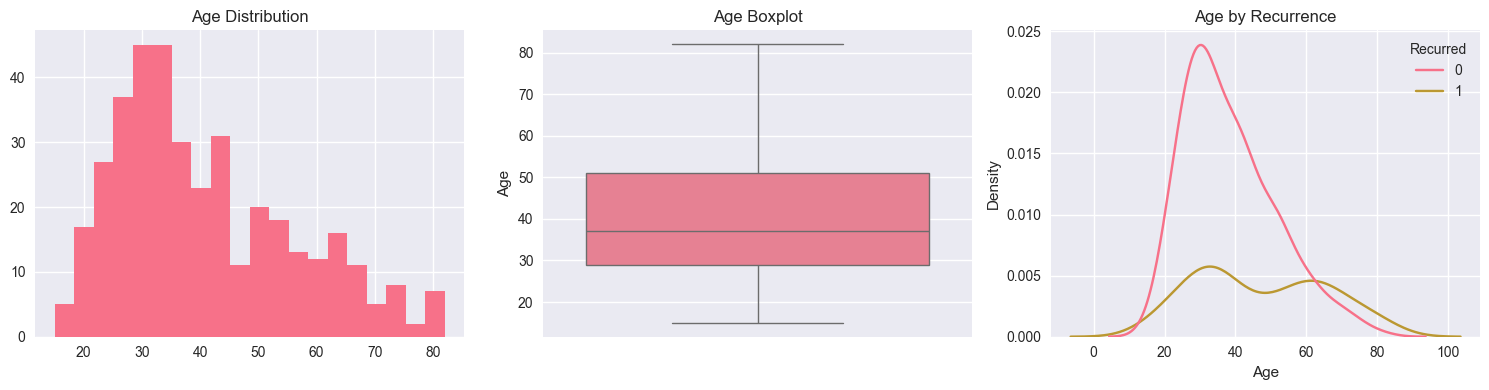

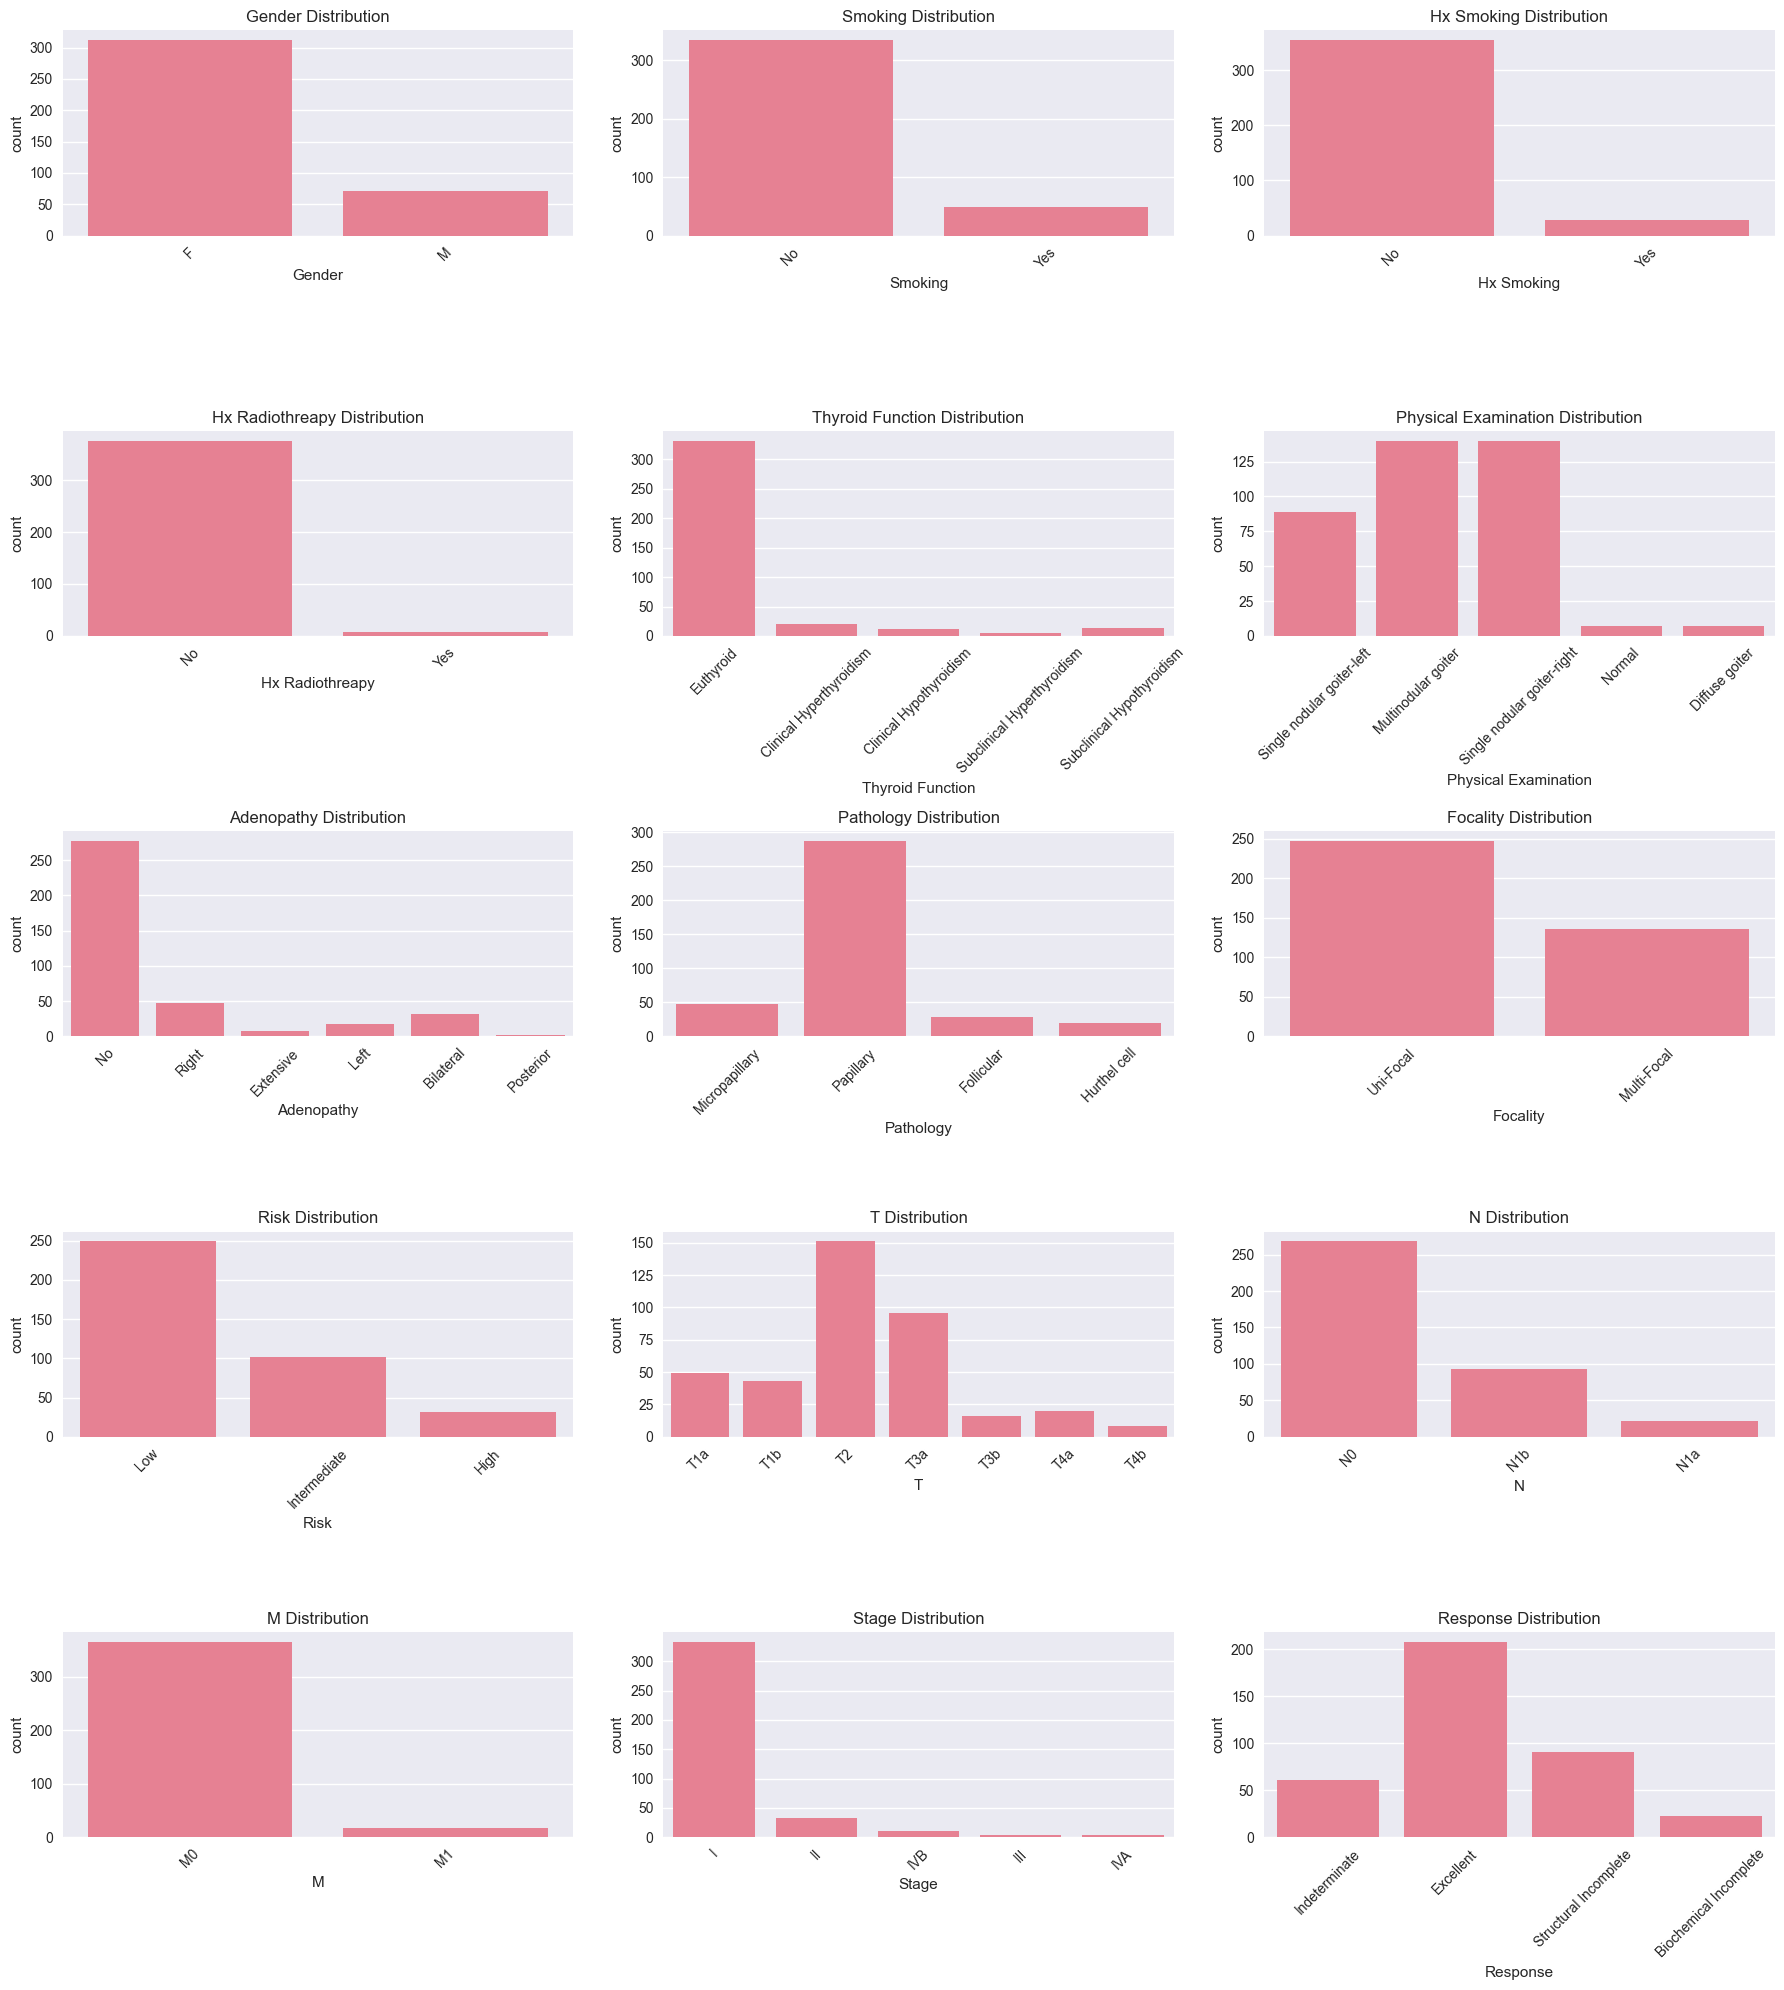

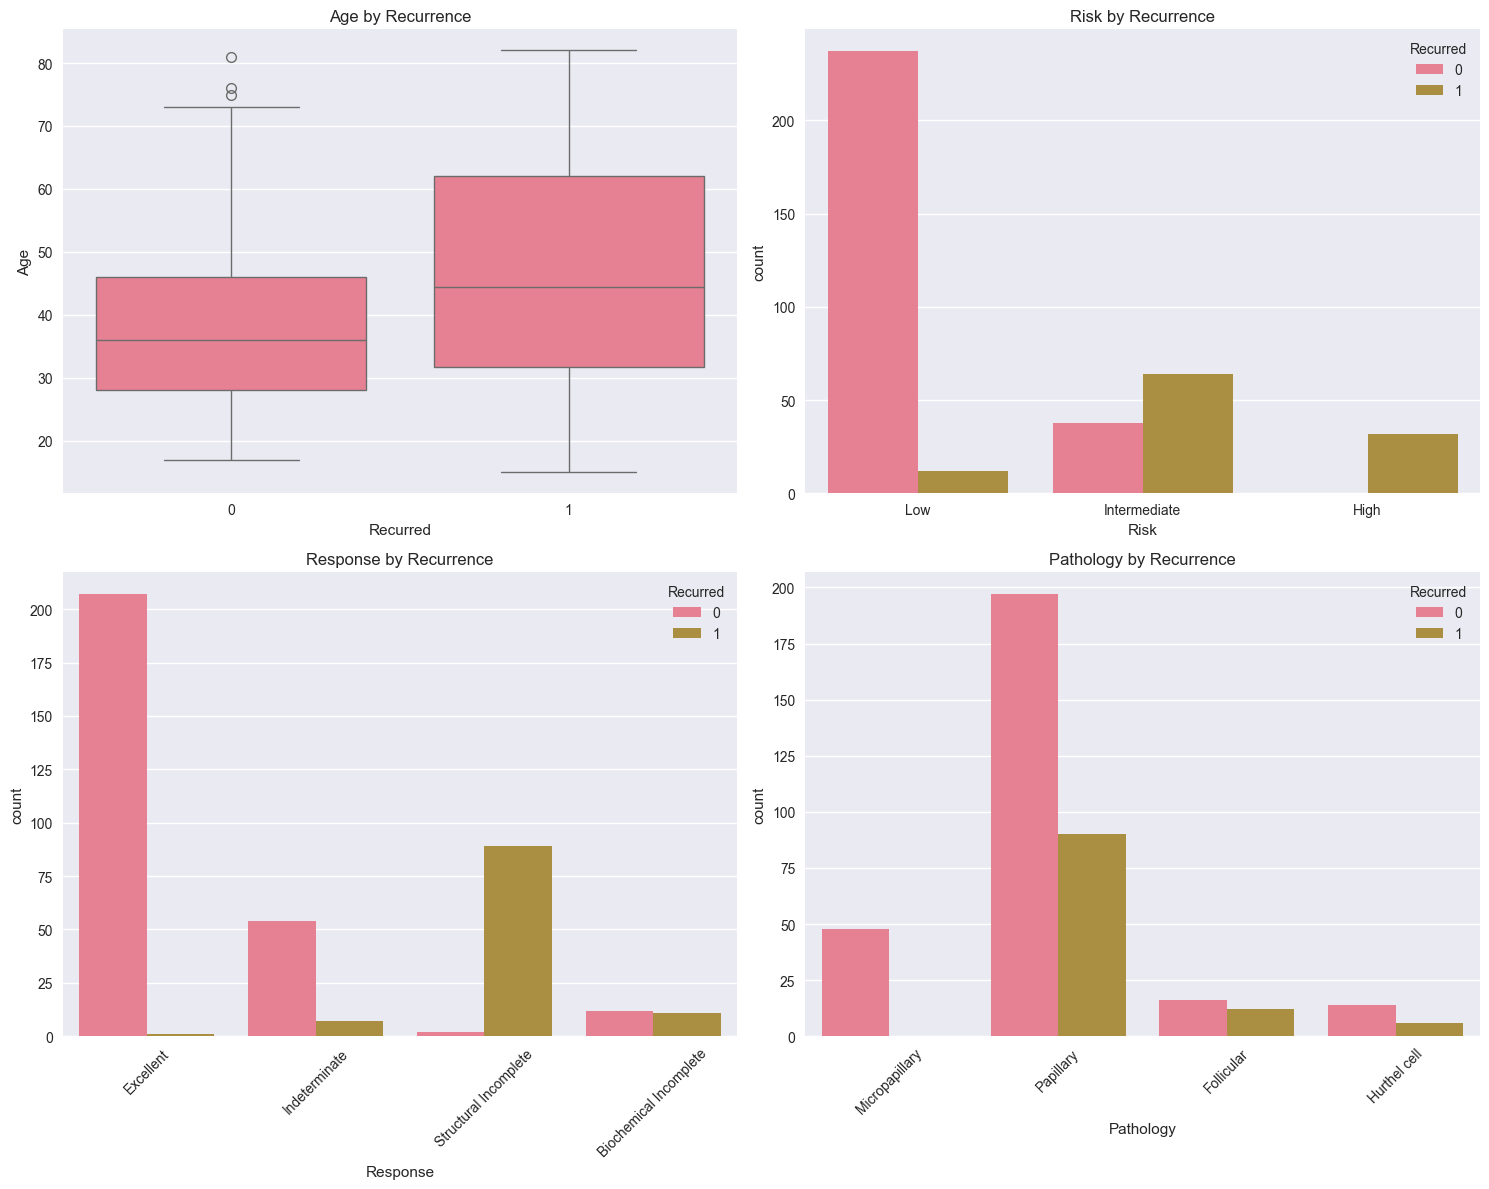

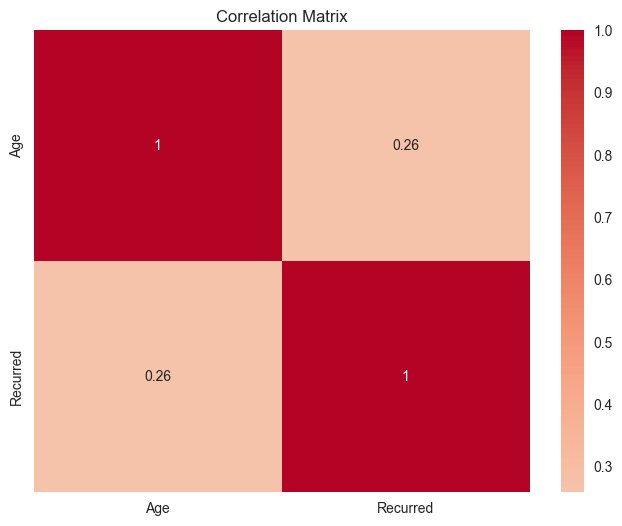

In [10]:
# Standardize target
df['Recurred'] = df['Recurred'].map({'No': 0, 'Yes': 1})

# Univariate analysis - Numeric
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Age'].hist(bins=20, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.boxplot(y=df['Age'], ax=axes[1])
axes[1].set_title('Age Boxplot')

sns.kdeplot(data=df, x='Age', hue='Recurred', ax=axes[2])
axes[2].set_title('Age by Recurrence')
plt.tight_layout()
plt.show()

# Categorical features
cat_features = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 
                'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 
                'T', 'N', 'M', 'Stage', 'Response']

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if i < len(axes):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'{col} Distribution')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Bivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age by recurrence
sns.boxplot(data=df, x='Recurred', y='Age', ax=axes[0, 0])
axes[0, 0].set_title('Age by Recurrence')

# Risk by recurrence
risk_order = ['Low', 'Intermediate', 'High']
sns.countplot(data=df, x='Risk', hue='Recurred', order=risk_order, ax=axes[0, 1])
axes[0, 1].set_title('Risk by Recurrence')

# Response by recurrence
response_order = ['Excellent', 'Indeterminate', 'Structural Incomplete', 'Biochemical Incomplete']
sns.countplot(data=df, x='Response', hue='Recurred', order=response_order, ax=axes[1, 0])
axes[1, 0].set_title('Response by Recurrence')
axes[1, 0].tick_params(axis='x', rotation=45)

# Pathology by recurrence
sns.countplot(data=df, x='Pathology', hue='Recurred', ax=axes[1, 1])
axes[1, 1].set_title('Pathology by Recurrence')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

## 3. Data Preprocessing and Feature Engineering

In [14]:
from sklearn.pipeline import Pipeline                      # sklearn pipeline for ColumnTransformer sub-pipelines
from imblearn.pipeline import Pipeline as ImbPipeline      # imblearn pipeline for resampling + classifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# --- Feature engineering (assume df already has these flags) ---
df['smoker_flag'] = ((df['Smoking'] == 'Yes') | (df['Hx Smoking'] == 'Yes')).astype(int)
df['hx_radiotherapy_flag'] = (df['Hx Radiothreapy'] == 'Yes').astype(int)
df['multifocal_flag'] = (df['Focality'] == 'Multi-Focal').astype(int)

# --- Feature lists ---
numeric_features = ['Age']
ordinal_features = ['Stage', 'Risk', 'Response']
nominal_features = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                    'Thyroid Function', 'Physical Examination', 'Adenopathy',
                    'Pathology', 'Focality', 'T', 'N', 'M',
                    'smoker_flag', 'hx_radiotherapy_flag', 'multifocal_flag']

# --- Ordinal mappings (categories must be in order) ---
ordinal_mappings = {
    'Stage': ['I', 'II', 'III', 'IV', 'IVA', 'IVB'],
    'Risk': ['Low', 'Intermediate', 'High'],
    'Response': ['Excellent', 'Indeterminate', 'Structural Incomplete', 'Biochemical Incomplete']
}
ordinal_categories = [ordinal_mappings[feat] for feat in ordinal_features]

# --- Sub-pipelines (IMPORTANT: steps MUST be tuples (name, estimator)) ---
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, dtype=float))
])

nominal_transformer = Pipeline(steps=[
    # NOTE: newer sklearn uses sparse_output instead of sparse
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# --- ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ],
    remainder='drop'   # or 'passthrough' if you want to keep other cols
)

# --- Train/test split ---
X = df.drop('Recurred', axis=1)
y = df['Recurred'].astype(int)   # ensure integer 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")


Training set: (306, 19), Test set: (77, 19)
Training target distribution: {0: 220, 1: 86}
Test target distribution: {0: 55, 1: 22}


## 4. Model Training and Evaluation

In [15]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, scale_pos_weight=len(y_train)/sum(y_train), 
                                eval_metric='logloss', use_label_encoder=False),
    'LightGBM': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, auto_class_weights='Balanced', verbose=False)
}

# Results storage
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Create pipeline with SMOTE
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Train on full training set
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'test_auc': roc_auc,
        'recall': report['1']['recall'],
        'precision': report['1']['precision'],
        'f1': report['1']['f1-score'],
        'pipeline': pipeline
    }
    
    print(f"CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    print(f"Test AUC: {roc_auc:.3f}")
    print(f"Recall: {report['1']['recall']:.3f}, Precision: {report['1']['precision']:.3f}")

# Select best model (highest recall for positive class)
best_model_name = max(results.keys(), key=lambda x: results[x]['recall'])
best_pipeline = results[best_model_name]['pipeline']

print(f"\nBest model: {best_model_name} (highest recall)")
print(f"Test Recall: {results[best_model_name]['recall']:.3f}")
print(f"Test Precision: {results[best_model_name]['precision']:.3f}")
print(f"Test AUC: {results[best_model_name]['test_auc']:.3f}")


Training Logistic Regression...
CV AUC: 0.976 (+/- 0.008)
Test AUC: 0.986
Recall: 0.955, Precision: 0.840

Training Random Forest...
CV AUC: 0.982 (+/- 0.037)
Test AUC: 0.990
Recall: 0.955, Precision: 1.000

Training XGBoost...
CV AUC: 0.981 (+/- 0.043)
Test AUC: 0.993
Recall: 0.955, Precision: 0.955

Training LightGBM...
CV AUC: 0.986 (+/- 0.033)
Test AUC: 0.994
Recall: 0.909, Precision: 0.952

Training CatBoost...
CV AUC: 0.985 (+/- 0.031)
Test AUC: 0.992
Recall: 0.909, Precision: 1.000

Best model: Logistic Regression (highest recall)
Test Recall: 0.955
Test Precision: 0.840
Test AUC: 0.986


## 5. Model Evaluation and Interpretability

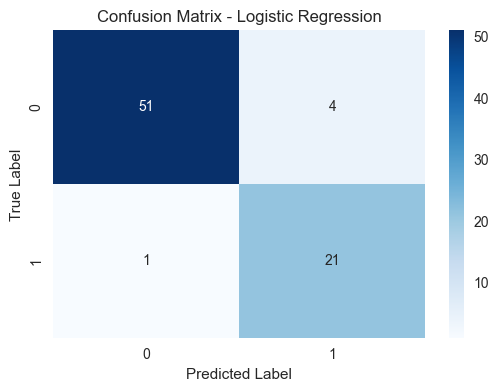

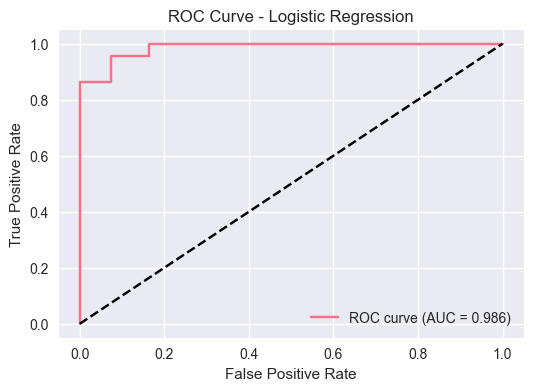

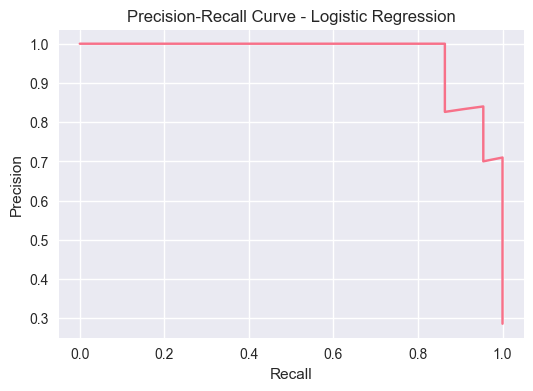

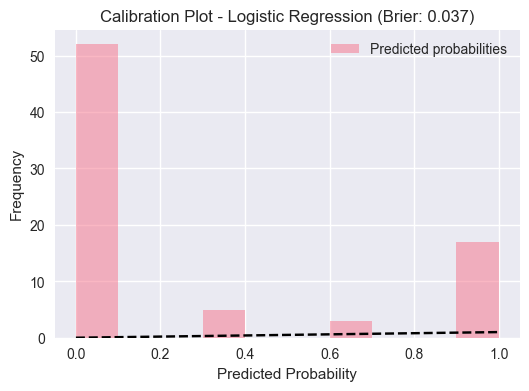

Computing SHAP values...
SHAP analysis not available for this model type


In [16]:
# Detailed evaluation of best model
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()

# Calibration
calibrated_clf = CalibratedClassifierCV(best_pipeline, method='isotonic', cv='prefit')
calibrated_clf.fit(X_train, y_train)
y_pred_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, y_pred_proba_cal)

plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')
plt.hist(y_pred_proba_cal, bins=10, alpha=0.5, label='Predicted probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title(f'Calibration Plot - {best_model_name} (Brier: {brier:.3f})')
plt.legend()
plt.show()

# SHAP Analysis
print("Computing SHAP values...")
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    explainer = shap.TreeExplainer(best_pipeline.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Global feature importance
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}')
    plt.show()
    
    # Local explanations for specific cases
    for i in [0, 1, 2]:  # First 3 test samples
        plt.figure(figsize=(8, 4))
        shap.waterfall_plot(shap.Explanation(values=shap_values[i], 
                                           base_values=explainer.expected_value,
                                           data=X_test_transformed[i]), 
                          show=False)
        plt.title(f'SHAP Waterfall Plot - Sample {i} (True: {y_test.iloc[i]}, Pred: {y_pred[i]})')
        plt.show()
else:
    print("SHAP analysis not available for this model type")

## 6. Save Artifacts

In [19]:
import os
# Create artifacts directory
os.makedirs('artifacts', exist_ok=True)

# Save model and pipeline
joblib.dump(best_pipeline, 'artifacts/model.joblib')
joblib.dump(preprocessor, 'artifacts/pipeline.joblib')

# Save metrics
metrics_summary = {
    'model': best_model_name,
    'test_auc': results[best_model_name]['test_auc'],
    'recall': results[best_model_name]['recall'],
    'precision': results[best_model_name]['precision'],
    'f1': results[best_model_name]['f1'],
    'brier_score': brier,
    'cv_auc_mean': results[best_model_name]['cv_auc_mean'],
    'cv_auc_std': results[best_model_name]['cv_auc_std'],
    'classification_report': classification_report(y_test, y_pred, output_dict=True)
}

joblib.dump(metrics_summary, 'artifacts/metrics_summary.json')

# Save plots
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('artifacts/confusion_matrix.png')
plt.close()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.savefig('artifacts/roc_curve.png')
plt.close()

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.savefig('artifacts/precision_recall_curve.png')
plt.close()

plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')
plt.hist(y_pred_proba_cal, bins=10, alpha=0.5, label='Predicted probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title(f'Calibration Plot - {best_model_name}')
plt.legend()
plt.savefig('artifacts/calibration_plot.png')
plt.close()

# Save SHAP plot if available
if 'shap_values' in locals():
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed, show=False)
    plt.savefig('artifacts/shap_summary.png')
    plt.close()

print("All artifacts saved to 'artifacts/' directory")

All artifacts saved to 'artifacts/' directory


## 7. Summary and Clinical Implications

### Model Performance
- **Best Model**: {best_model_name}
- **Test AUC**: {results[best_model_name]['test_auc']:.3f}
- **Recall (Sensitivity)**: {results[best_model_name]['recall']:.3f} - Critical for not missing recurrences
- **Precision**: {results[best_model_name]['precision']:.3f}
- **F1-Score**: {results[best_model_name]['f1']:.3f}

### Key Findings
- Risk level, Response to treatment, and Pathology are the strongest predictors
- Age shows some association with recurrence risk
- Multifocal tumors and certain TNM stages increase risk

### Clinical Use
- Model prioritizes sensitivity to minimize missed recurrences
- Should be used as decision-support tool, not standalone diagnostic
- Requires prospective validation before clinical deployment
- Consider cost-benefit of false positives vs. missed recurrences

### Limitations
- Retrospective data from single institution
- Class imbalance addressed but may affect generalizability
- No external validation dataset
- Temporal trends not assessed